In [1]:
import pandas as pd
import numpy as np
import os, glob
import re
import seaborn as sns
from pathlib import Path
from sklearn.error_df import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, mean_absolute_percentage_error, mean_squared_log_error, root_mean_squared_error, root_mean_squared_error

In [59]:
full=False
if full:
    remove_list = ['dft']
else:
    remove_list = ['dft', '7net-0', '7net-l3i5', '7net-omat']

In [60]:
df = pd.read_csv('./250901_E_bind_full.csv')
df.drop(columns=['solute'], inplace=True)
mlip_list = df.columns.tolist()
for r in remove_list:
    mlip_list.remove(r)
    
for mlip in mlip_list:
    df[mlip+'_delta'] = df[mlip] - df['dft']
df.to_csv('./250901_delta.csv', index=False)
df.reset_index(inplace=True)

In [61]:
sns_df = pd.DataFrame(columns=['index','dft', 'mlip', 'pred','delta','abs_error'], index=range(len(mlip_list)*len(df)))
idx = 0
for i in range(len(df)):
    for mlip in mlip_list:
        sns_df.loc[idx, 'index'] = i
        sns_df.loc[idx, 'dft'] = df.loc[i, 'dft']
        sns_df.loc[idx, 'mlip'] =  mlip
        sns_df.loc[idx, 'pred'] = df.loc[i, mlip]
        sns_df.loc[idx, 'delta'] = df.loc[i, mlip+'_delta']
        sns_df.loc[idx, 'abs_error'] = abs(df.loc[i, mlip+'_delta'])
        idx += 1
sns_df.to_csv('./250901_sns.csv', index=False)

In [71]:
error_df = pd.DataFrame(columns = mlip_list)
true_value = df['dft']
for col in mlip_list:
    pred_value = df[col]
    error_df.loc['MAE', col] = mean_absolute_error(true_value, pred_value)
    error_df.loc['MSE', col] = mean_squared_error(true_value, pred_value)
    error_df.loc['RMSE', col] = np.sqrt(mean_squared_error(true_value, pred_value))
    error_df.loc['R2', col] = r2_score(true_value, pred_value)
    # error_df.loc['Explained Variance', col] = explained_variance_score(true_value, pred_value)
    error_df.loc['MAPE', col] = mean_absolute_percentage_error(true_value, pred_value)

error_df.to_csv('./250901_error.csv', index=True)
error_df



,ompa-mpa,ompa-omat24,omni-mpa,omni-omat24,orb_mpa,orb_omat,dpa-mp,dpa-omat,esen_omat
MAE,0.160405,0.17306,0.158391,0.154301,0.146271,0.125125,0.140661,0.189873,0.105544
MSE,0.060763,0.068879,0.048347,0.045106,0.033052,0.028988,0.038637,0.072104,0.023133
RMSE,0.246502,0.262449,0.21988,0.212381,0.181803,0.170258,0.196562,0.268522,0.152096
R2,0.825191,0.801841,0.86091,0.870236,0.904912,0.916606,0.888847,0.792564,0.933448
MAPE,1.29238,1.456561,0.961561,0.998129,1.077103,0.66449,0.788274,1.224413,0.617236


In [68]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica','Arial']
# plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titlelocation'] = 'right'
plt.rcParams['axes.titlepad'] = 3

plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.labelbottom'] = True    
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.loc'] = 'lower right'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'in'

plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.facecolor'] = 'white'

plt.rcParams['figure.figsize'] = 3.4, 2.5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.subplot.bottom'] = 0.18
plt.rcParams['figure.subplot.left'] = 0.1
plt.rcParams['figure.subplot.right'] = 0.97
plt.rcParams['figure.subplot.top'] = 0.98
plt.rcParams['figure.subplot.wspace'] = 0.05
plt.rcParams['figure.subplot.hspace'] = 0.03


color_dict= {
    'ompa-omat24': '#02baae',
    'ompa-mpa': '#72b8b3',
    '7net-omat': '#c1ded8',
    'omni-omat24': '#0073ff',
    'omni-mpa': '#8cbbf5',
    '7net-l3i5': '#0a8a2c',
    '7net-0': '#89c99a',
    'orb_omat': '#d48f3f',
    'orb_mpa': '#d9ba98',
    'esen_omat':'#e8d803',
    'esen_oam': '#f5ea74',
    'dpa-mp': '#d19adf',
    'dpa-omat': '#e829f6',
}


In [69]:
def plot_box(sns_df,filename):
    plt.figure(figsize=(15,6.5))
    vlines = [i+0.5 for i in range(len(mlip_list)-1)]
    sns.boxplot(
        data=sns_df,
        x="mlip",
        y="delta",
        palette=color_dict,
        whis=(5, 95),
        showfliers=True,
        width=0.6
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=0)
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.axhline(0, color="k", linestyle="--", linewidth=1,zorder=0)  # reference line
    for v in vlines:
        plt.axvline(v, color="grey", linestyle="--", linewidth=1,zorder=0)
    plt.ylabel(r"$\Delta E_{\mathrm{bind}}$ (eV)")
    plt.xlabel("")
        
    plt.tick_params(axis="x", which="major", pad=5)
    plt.savefig(filename, transparent=True)
    # plt.close()
    plt.show()
    print(f'Box plot saved as {filename}')


In [72]:
def plot_violin(sns_df, filename):
    plt.figure(figsize=(15,5.5))
    sns.violinplot(
        data=sns_df,
        x="mlip",
        y="delta",          
        inner="quartile",
        cut=0,
        palette=color_dict
    )
    plt.xticks(ticks=range(len(mlip_list)), labels=mlip_list, ha='center', rotation=0)
    plt.axhline(0, color="k", linestyle="--", linewidth=1)  # reference line
    ylabel = r"$\Delta E_{\mathrm{bind}}$ (eV)"
    plt.xlabel("")
    
    # sns.despine()
    
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tight_layout()
    plt.show()
    plt.savefig(filename, transparent=True)
    print(f'Violin plot saved as {filename}')


/var/folders/s6/8wvn2dhd0jj9m3bd1l0c6lnm0000gn/T/ipykernel_27077/763423565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


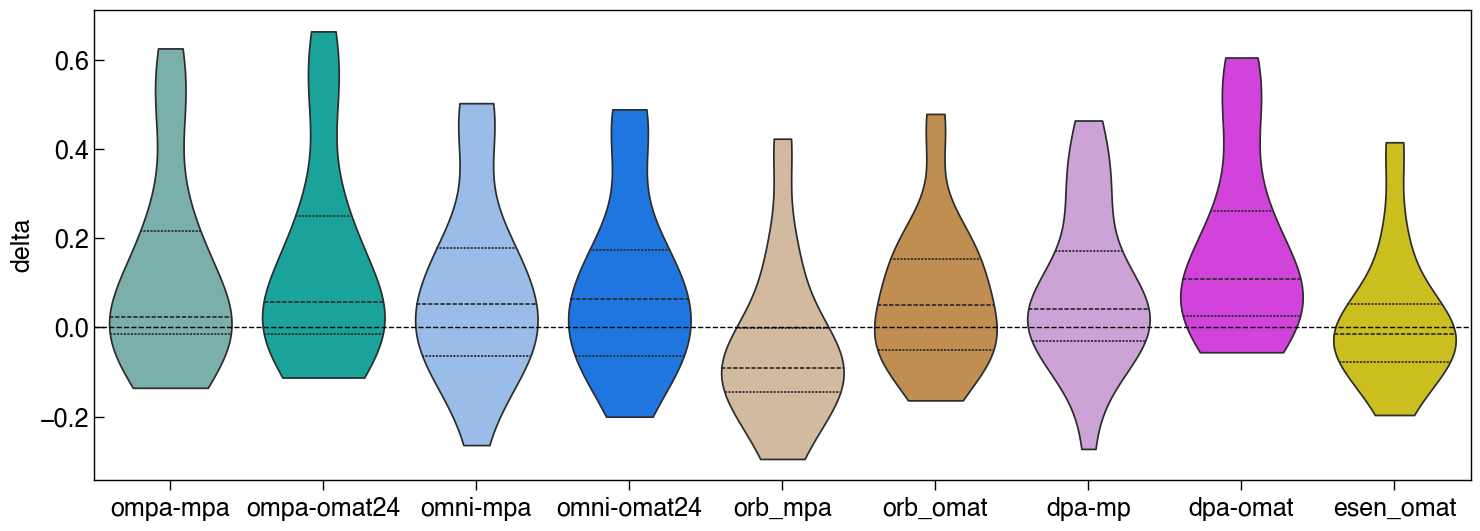

Violin plot saved as 250901_violin.png


<Figure size 340x250 with 0 Axes>

In [73]:
plot_violin(sns_df, '250901_violin.png')